In [3]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

In [4]:
project_root = Path('..').resolve()

candidate_paths = [
    project_root / 'NASA_access_log_Jul95',
    project_root / 'NASA_access_log_Aug95',
    project_root / 'data' / 'raw' / 'NASA_access_log_Jul95',
    project_root / 'data' / 'raw' / 'NASA_access_log_Aug95',
]

for p in candidate_paths:
    print(f'{p.name}:', 'FOUND' if p.exists() else 'MISSING')

NASA_access_log_Jul95: FOUND
NASA_access_log_Aug95: FOUND
NASA_access_log_Jul95: MISSING
NASA_access_log_Aug95: MISSING


In [5]:
def _find_log_file(filename: str) -> Path:
    locations = [
        project_root / filename,
        project_root / 'data' / 'raw' / filename,
    ]
    for path in locations:
        if path.exists():
            return path
    raise FileNotFoundError(f'Could not locate {filename} in expected locations.')


def read_lines(path: Path) -> pd.DataFrame:
    lines = path.read_text(errors='replace').splitlines()
    return pd.DataFrame({'raw_line': lines, 'source_file': path.name})


jul_path = _find_log_file('NASA_access_log_Jul95')
aug_path = _find_log_file('NASA_access_log_Aug95')

# Build two source-specific DataFrames first
df_jul = read_lines(jul_path)
df_aug = read_lines(aug_path)

# Merge the two DataFrames into one unified DataFrame
df_raw = pd.concat([df_jul, df_aug], ignore_index=True)
df_raw.head()

,raw_line,source_file
0,199.72.81.55 - - [01/Jul/1995:00:00:01 -0400] ...,NASA_access_log_Jul95
1,unicomp6.unicomp.net - - [01/Jul/1995:00:00:06...,NASA_access_log_Jul95
2,199.120.110.21 - - [01/Jul/1995:00:00:09 -0400...,NASA_access_log_Jul95
3,burger.letters.com - - [01/Jul/1995:00:00:11 -...,NASA_access_log_Jul95
4,199.120.110.21 - - [01/Jul/1995:00:00:11 -0400...,NASA_access_log_Jul95


## Manual Feature Extraction
In this section, we manually create model-friendly features from parsed logs.

Features created include:
- request method, endpoint, and protocol from the request text
- temporal features such as hour, day, and weekday
- binary flags like error request and GET request
- path complexity (endpoint depth)
- transformed traffic size using `bytes_log1p` for scale stabilization

These features give us a structured baseline before text vectorization.

In [6]:
pattern = re.compile(
    r'^(?P<host>\S+)\s+(?P<ident>\S+)\s+(?P<authuser>\S+)\s+\[(?P<datetime>[^\]]+)\]\s+"(?P<request>[^"]*)"\s+(?P<status>\d{3}|-)\s+(?P<bytes>\d+|-)$'
)

parsed = df_raw['raw_line'].str.extract(pattern)
df = pd.concat([df_raw, parsed], axis=1)

df['status'] = pd.to_numeric(df['status'], errors='coerce')
df['bytes'] = pd.to_numeric(df['bytes'], errors='coerce')
df['datetime'] = pd.to_datetime(df['datetime'], format='%d/%b/%Y:%H:%M:%S %z', errors='coerce')

df['parse_ok'] = df[['host', 'request', 'status']].notna().all(axis=1)

# Manual feature engineering
df_features = df.loc[df['parse_ok']].copy()
request_parts = df_features['request'].str.extract(
    r'^(?P<method>\S+)\s+(?P<endpoint>\S+)\s*(?P<protocol>HTTP/\d\.\d)?$'
 )

df_features = pd.concat([df_features, request_parts], axis=1)
df_features['hour'] = df_features['datetime'].dt.hour
df_features['day'] = df_features['datetime'].dt.day
df_features['weekday'] = df_features['datetime'].dt.day_name()
df_features['is_error'] = (df_features['status'] >= 400).astype(int)
df_features['is_get'] = (df_features['method'] == 'GET').astype(int)
df_features['endpoint_depth'] = df_features['endpoint'].fillna('').str.count('/')
df_features['bytes_filled'] = df_features['bytes'].fillna(0)
df_features['bytes_log1p'] = np.log1p(df_features['bytes_filled'].clip(lower=0))

df_features[[
    'host', 'status', 'bytes', 'method', 'endpoint',
    'hour', 'weekday', 'is_error', 'endpoint_depth', 'bytes_log1p'
 ]].head()

,host,status,bytes,method,endpoint,hour,weekday,is_error,endpoint_depth,bytes_log1p
0,199.72.81.55,200.0,6245.0,GET,/history/apollo/,0,Saturday,0,3,8.739697
1,unicomp6.unicomp.net,200.0,3985.0,GET,/shuttle/countdown/,0,Saturday,0,3,8.290544
2,199.120.110.21,200.0,4085.0,GET,/shuttle/missions/sts-73/mission-sts-73.html,0,Saturday,0,4,8.315322
3,burger.letters.com,304.0,0.0,GET,/shuttle/countdown/liftoff.html,0,Saturday,0,3,0.000000
4,199.120.110.21,200.0,4179.0,GET,/shuttle/missions/sts-73/sts-73-patch-small.gif,0,Saturday,0,4,8.338067


## Status Code Percentage Summary
Here we summarize how often each HTTP status code appears in the dataset.

This helps us understand the class distribution before modeling and makes the response behavior easier to compare across status numbers.

,status,count,percentage
0,200.0,3100520,89.57
1,304.0,266773,7.71
2,302.0,73070,2.11
3,404.0,20869,0.60
4,403.0,224,0.01
5,500.0,65,0.00
6,501.0,41,0.00
7,400.0,11,0.00


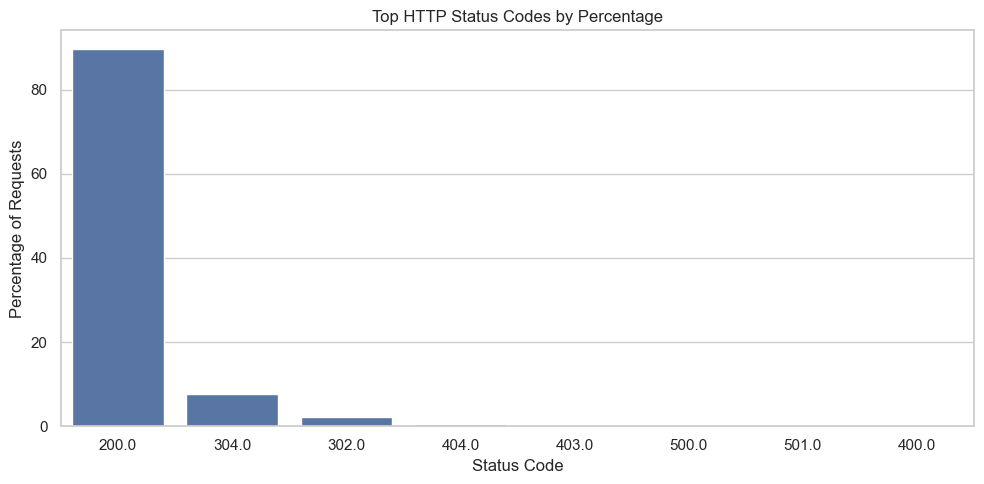

In [10]:
# Status code percentage summary
status_summary = (
    df_features['status']
    .value_counts(dropna=False)
    .rename_axis('status')
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
 )

status_summary['percentage'] = (status_summary['count'] / status_summary['count'].sum() * 100).round(2)

display(status_summary.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=status_summary.head(10), x=status_summary.head(10)['status'].astype(str), y='percentage')
plt.title('Top HTTP Status Codes by Percentage')
plt.xlabel('Status Code')
plt.ylabel('Percentage of Requests')
plt.tight_layout()
plt.show()

## TF-IDF Vectorization
This step converts request text into a numeric matrix using term frequency-inverse document frequency.

What this does:
- builds text features from endpoint or request text
- down-weights very common tokens and highlights informative tokens
- creates a sparse matrix `X_tfidf` ready for dimensionality reduction or modeling

In [7]:
# TF-IDF implementation on request text
text_series = df_features['endpoint'].fillna(df_features['request']).fillna('')

max_docs = 200000
if len(text_series) > max_docs:
    text_series = text_series.sample(max_docs, random_state=42)

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z0-9_]+\b',
    max_features=5000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
)

X_tfidf = tfidf_vectorizer.fit_transform(text_series)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print('TF-IDF input rows:', len(text_series))
print('TF-IDF matrix shape:', X_tfidf.shape)

mean_tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_idx = np.argsort(mean_tfidf_scores)[-20:][::-1]

top_tfidf_terms = pd.DataFrame({
    'term': tfidf_feature_names[top_idx],
    'mean_tfidf': mean_tfidf_scores[top_idx],
})
display(top_tfidf_terms)

TF-IDF input rows: 200000
TF-IDF matrix shape: (200000, 2082)


,term,mean_tfidf
0,images,0.090310
1,gif,0.086319
2,logosmall,0.067611
3,logosmall gif,0.067610
4,sts,0.060845
5,shuttle,0.059347
6,apollo,0.057063
7,missions,0.047987
8,html,0.046511
9,shuttle missions,0.044350


## PCA (via TruncatedSVD)
Because TF-IDF is sparse, we use TruncatedSVD as a PCA-style reduction method.

Why we use it:
- reduces high-dimensional TF-IDF vectors to compact components
- preserves most variance while lowering noise and compute cost
- makes data easier to visualize and use in downstream models

Reduced matrix shape: (200000, 50)
Total explained variance (50 components): 0.7793


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.056899,0.056899
1,2,0.073050,0.129949
2,3,0.061235,0.191184
3,4,0.045252,0.236436
4,5,0.038156,0.274592
5,6,0.036625,0.311217
6,7,0.031509,0.342726
7,8,0.030278,0.373004
8,9,0.030107,0.403111
9,10,0.030082,0.433193


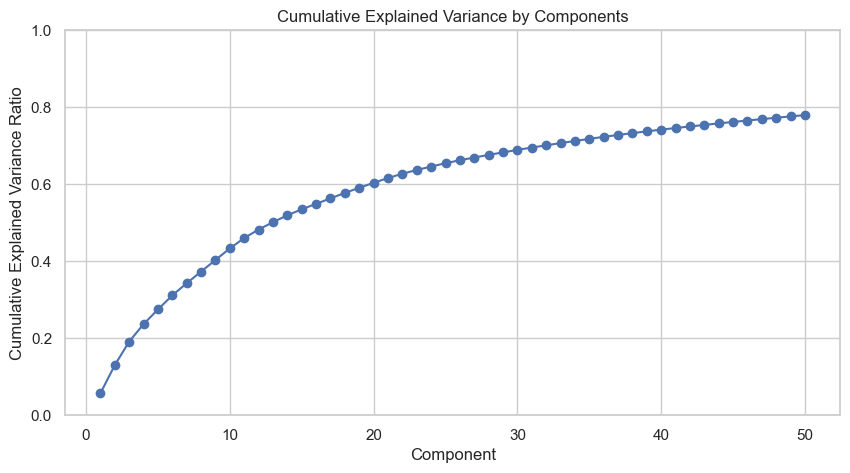

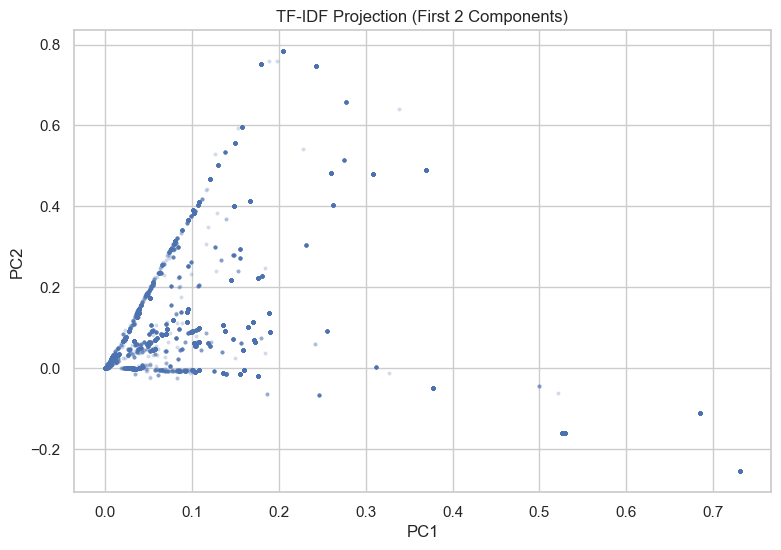

In [8]:
# PCA-like dimensionality reduction for sparse TF-IDF (using TruncatedSVD)
n_components = 50
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_tfidf_pca = svd.fit_transform(X_tfidf)

explained_ratio = svd.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

print('Reduced matrix shape:', X_tfidf_pca.shape)
print('Total explained variance (50 components):', round(cum_explained[-1], 4))

pca_summary = pd.DataFrame({
    'component': np.arange(1, n_components + 1),
    'explained_variance_ratio': explained_ratio,
    'cumulative_explained_variance': cum_explained,
})
display(pca_summary.head(10))

plt.figure(figsize=(10, 5))
plt.plot(pca_summary['component'], pca_summary['cumulative_explained_variance'], marker='o')
plt.title('Cumulative Explained Variance by Components')
plt.xlabel('Component')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.ylim(0, 1)
plt.show()

plot_sample_size = min(20000, X_tfidf_pca.shape[0])
plot_idx = np.random.RandomState(42).choice(X_tfidf_pca.shape[0], size=plot_sample_size, replace=False)

pca_plot_df = pd.DataFrame({
    'pc1': X_tfidf_pca[plot_idx, 0],
    'pc2': X_tfidf_pca[plot_idx, 1],
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_plot_df, x='pc1', y='pc2', s=8, alpha=0.25, linewidth=0)
plt.title('TF-IDF Projection (First 2 Components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [11]:
from zipfile import ZipFile

output_dir = project_root / 'artifacts'
output_dir.mkdir(exist_ok=True)

training_dir = output_dir / 'model_training'
training_dir.mkdir(exist_ok=True)

# (a) Small sample of the dataset
sample_size = min(1000, len(df_features))
sample_data = df_features.sample(sample_size, random_state=42).copy()
sample_data_path = output_dir / 'nasa_access_log_feature_sample.csv'
sample_data.to_csv(sample_data_path, index=False)

# Save the full manual feature table for later model training
full_features_path = training_dir / 'manual_features_full.csv'
df_features.to_csv(full_features_path, index=False)

# Save PCA features for the sampled TF-IDF rows
pca_feature_columns = [f'pc{i}' for i in range(1, X_tfidf_pca.shape[1] + 1)]
pca_features_df = pd.DataFrame(X_tfidf_pca, columns=pca_feature_columns, index=text_series.index)
pca_features_path = training_dir / 'tfidf_pca_features.csv'
pca_features_df.to_csv(pca_features_path, index=True)

# (b) Feature extraction code package
code_zip_path = output_dir / 'feature_extraction_code.zip'
with ZipFile(code_zip_path, 'w') as zip_file:
    zip_file.write(project_root / 'notebooks' / '01_nasa_logs_feature_extract.ipynb', arcname='01_nasa_logs_feature_extract.ipynb')

# (c) Save PCA visualization as a single image
pca_viz_path = output_dir / 'tfidf_pca_visualization.png'
plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_plot_df, x='pc1', y='pc2', s=8, alpha=0.25, linewidth=0)
plt.title('TF-IDF Projection (First 2 Components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig(pca_viz_path, dpi=300, bbox_inches='tight')
plt.close()

print('Saved sample dataset to:', sample_data_path)
print('Saved full manual features to:', full_features_path)
print('Saved PCA feature set to:', pca_features_path)
print('Saved code archive to:', code_zip_path)
print('Saved PCA visualization to:', pca_viz_path)

Saved sample dataset to: /Users/sidqian/Downloads/Code/log-ml/artifacts/nasa_access_log_feature_sample.csv
Saved full manual features to: /Users/sidqian/Downloads/Code/log-ml/artifacts/model_training/manual_features_full.csv
Saved PCA feature set to: /Users/sidqian/Downloads/Code/log-ml/artifacts/model_training/tfidf_pca_features.csv
Saved code archive to: /Users/sidqian/Downloads/Code/log-ml/artifacts/feature_extraction_code.zip
Saved PCA visualization to: /Users/sidqian/Downloads/Code/log-ml/artifacts/tfidf_pca_visualization.png
